In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn

1. ANÁLISE EXPLORATÓRIA DE DADOS

In [2]:
df = pd.read_csv('manutencao_preditiva.csv')

In [3]:
#Dimensoes do dataset:
num_linhas, num_colunas = df.shape
print(f"O dataset possui {num_linhas} linhas e {num_colunas} colunas.")

O dataset possui 10000 linhas e 14 colunas.


In [4]:
# Tipos de dados das variáveis:

display(df.dtypes)

udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
potencia                   float64
dtype: object

In [5]:
#Resumo estatístico das colunas numéricas usando ".describe()":
display(df.describe())


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5000.50000,300.002158,310.000895,1537.483000,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190,59961.210585
std,2886.89568,1.951000,1.448791,175.876343,9.742337,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355,9951.106738
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,10966.800000
25%,2500.75000,298.400000,308.900000,1427.000000,33.600000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,53497.050000
50%,5000.50000,300.002158,310.000895,1504.000000,39.974168,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,60121.149305
75%,7500.25000,301.400000,311.000000,1606.000000,46.400000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,66412.975000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,99980.400000


1.2. ANÁLISE GRÁFICA

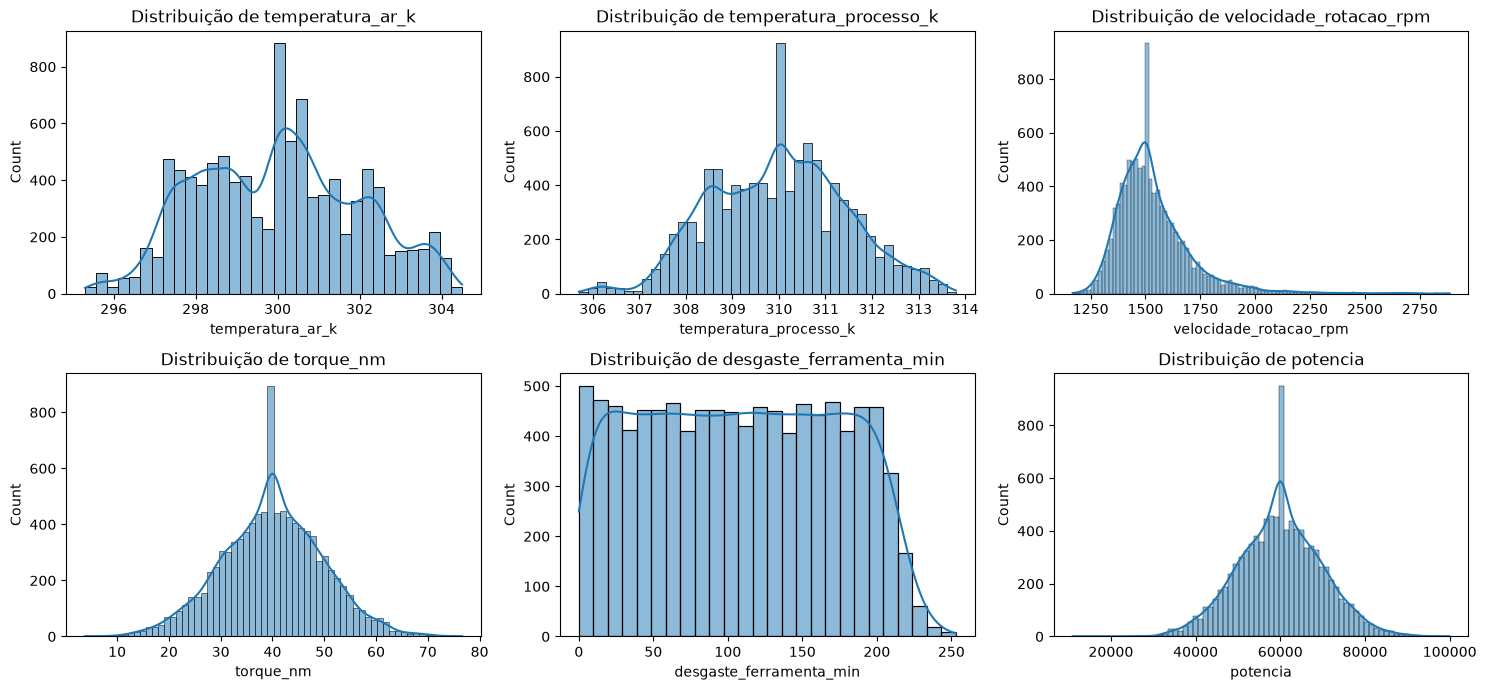

In [ ]:
#HISTOGRAMA PARA DEMONSTRAÇÃO DA DISTRIBUIÇÃO DE VARIÁVEIS PREDITORAS:
predictive_features = df.drop(columns=['udi','falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']).select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(predictive_features):
    plt.subplot(3, 3, i + 1) # Ajuste o grid conforme o número de variáveis
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

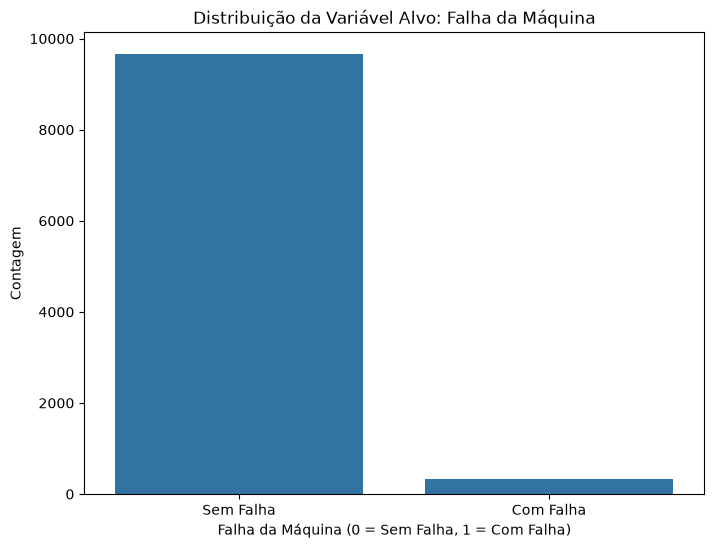

Porcentagem de máquinas sem falha: 96.61%
Porcentagem de máquinas com falha: 3.39%


In [7]:
#GRÁFICO BARRAS PARA DEMONSTRAR O DESBALANCEAMENTO DA VARIÁVEL ALVO:

plt.figure(figsize=(8, 6))
sns.countplot(x='falha_maquina', data=df)
plt.title('Distribuição da Variável Alvo: Falha da Máquina')
plt.xlabel('Falha da Máquina (0 = Sem Falha, 1 = Com Falha)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Sem Falha', 'Com Falha'])
plt.show()

falha_counts = df['falha_maquina'].value_counts(normalize=True) * 100
print(f"Porcentagem de máquinas sem falha: {falha_counts[0]:.2f}%")
print(f"Porcentagem de máquinas com falha: {falha_counts[1]:.2f}%")

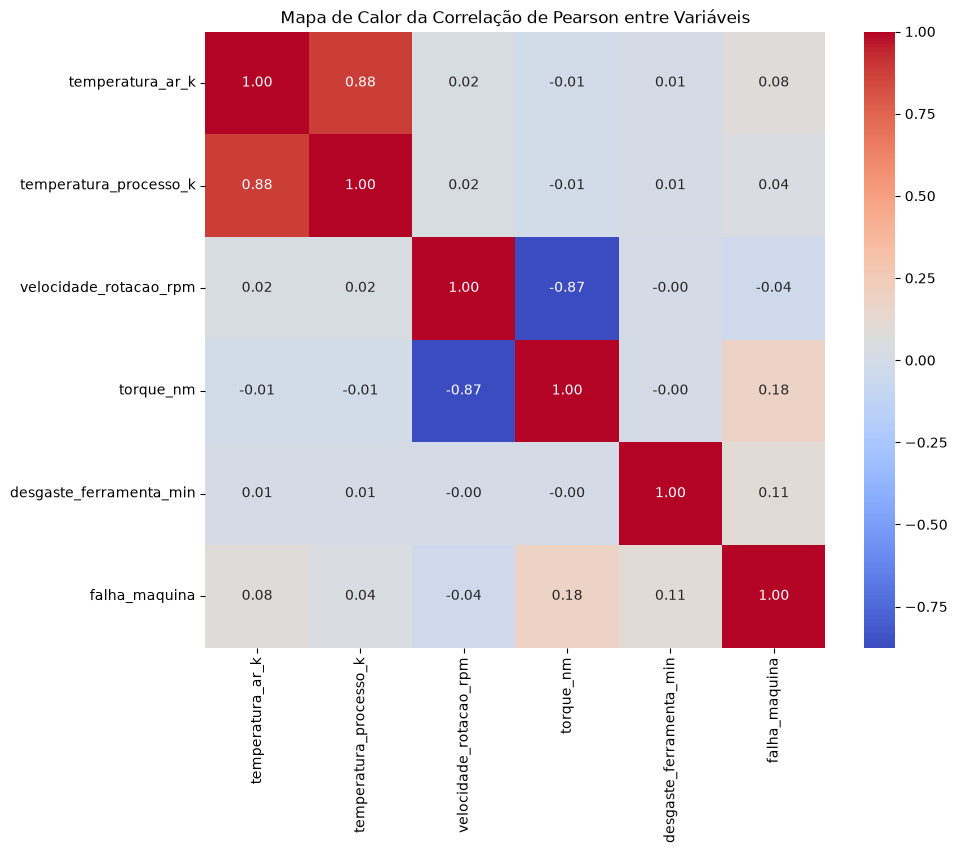

In [ ]:
# MAPA DE CALOR - CORRELAÇÃO DE PEARSON:
# Excluídas as colunas de identificação e colunas de falha que não são a variável alvo.

correlation_features = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina']
plt.figure(figsize=(10, 8))
sns.heatmap(df[correlation_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis')
plt.show()

Conclusões sobre os gráficos previamente gerados:
1. As curvas de "sino" mostram a distribuição normal (estatística) das variáveis contínuas, em geral simétricas com ligeira assimetria em alguns casos e picos em baixa frequencia para velocidade de rotação e torque, como esperado, pois faz sentido que máquinas operem em condições normais, não em extremos, o que certamente causaria maior desgaste e falhas, por consequência. 
2. O gráfico de barras comprova o desbalanceamento dos dados, e uma taxa de falha abaixo de 4%.
3. Para este modelo, o mapa de calor de Pearson apresenta correlação da variável alvo com o desgaste da ferramenta e o torque, e a relação inversa do torque com a velocidade. Além disso, ele também indica a multicolinearidade entre as temperaturas, o que pode afetar alguns modelos lineares.

2. DATA PREP - LIMPEZA E TRATAMENTO DE DADOS

In [9]:
# Remover linhas duplicadas
linhas_duplicadas = df.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {linhas_duplicadas}")

if linhas_duplicadas > 0:
    df_cleaned = df.drop_duplicates().copy()
    print(f"Número de linhas após a remoção de duplicadas: {len(df_cleaned)}")
else:
    df_cleaned = df.copy()
    print("Nenhuma linha duplicada encontrada.")

# Para atualizar o DataFrame principal
df = df_cleaned 


Número de linhas duplicadas encontradas: 0
Nenhuma linha duplicada encontrada.


In [ ]:
# Tratar dados ausentes, preenchendo com a média ou mediana.

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

print("Dados ausentes por coluna:")
if not missing_data.empty:
    display(missing_data)

    # Imputar dados ausentes em colunas numéricas
    numeric_cols_with_missing = df[missing_data.index].select_dtypes(include=['number']).columns

    if not numeric_cols_with_missing.empty:
        print("Imputando dados ausentes em colunas numéricas...")
        for col in numeric_cols_with_missing:
            
    # Como visto anteriormente, as variáveis 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm' e 'torque_nm' apresentam distribuições normal, com uma ligeira assimetria, e portanto preencher os dados com a média seria uma escolha razoável.
    # Porém, vamos calcular a skewness (assimetria) para verificar.
            
            # Verificando assimetria
            assimetria = df[col].skew()
            print(f"Assimetria da coluna '{col}': {assimetria:.2f}")

            if abs(assimetria) > 0.5:  # Parâmetro que indica assimetria significativa
                df[col] = df[col].fillna(df[col].median())
                print(f"Dados ausentes na coluna '{col}' completados com a MEDIANA devido à distribuição assimétrica.")
            else:
                df[col] = df[col].fillna(df[col].mean())
                print(f"Dados ausentes na coluna '{col}' completados com a MÉDIA devido à distribuição simétrica.")
    else:
        print("Não há colunas numéricas com dados ausentes.")
   
else:
    print("Nenhum dado ausente encontrado.")

print("Verificação final de dados ausentes:")
display(df.isnull().sum())

Dados ausentes por coluna:
Nenhum dado ausente encontrado.
Verificação final de dados ausentes:


udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
potencia                   0
dtype: int64

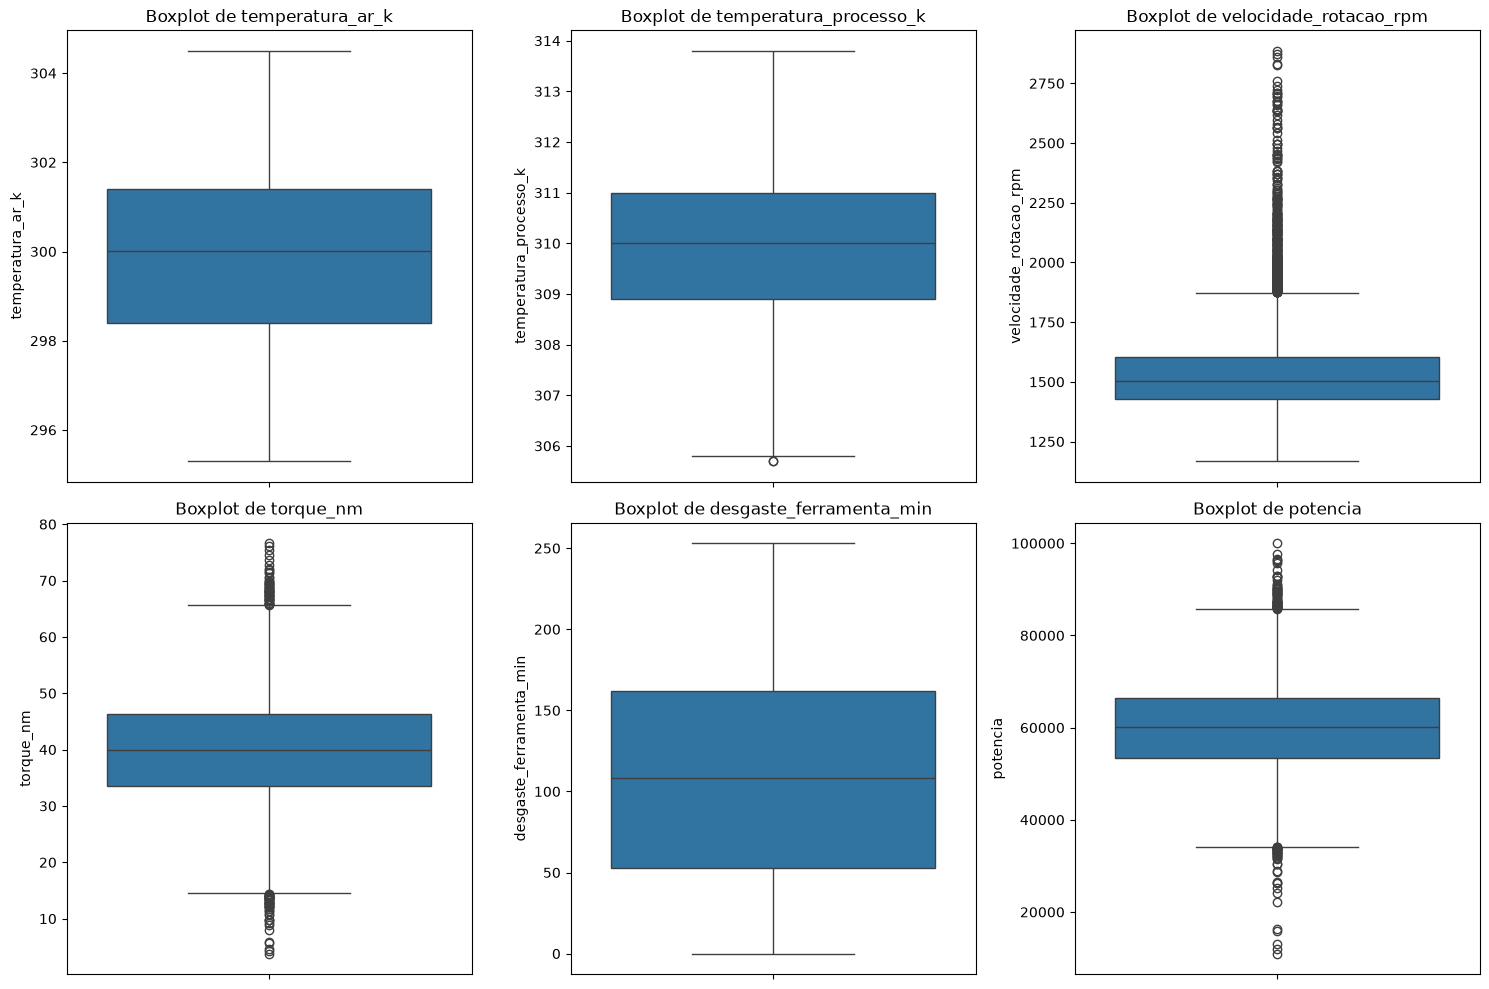

In [ ]:
#GRÁFICO BOXPLOT - IDENTIFICAÇÃO DE OUTLIERS

# Considerar somente colunas numéricas explicativas e excluir colunas de id, alvo e outras falhas de caráter informativo
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
explanatory_numeric_cols = [col for col in numeric_cols if col not in ['udi', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']]

plt.figure(figsize=(15, 10))
for i, col in enumerate(explanatory_numeric_cols):
    plt.subplot(2, 3, i + 1) 
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

3. FEATURE ENGINEERING 
obs.: dados nulos e ausentes já foram tratados previamente

In [13]:
# Criando uma variável Potência:

df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']
print("Coluna 'potencia' criada com sucesso.")
display(df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head())

Coluna 'potencia' criada com sucesso.


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.800000,66382.800000
1,1408.0,46.300000,65190.400000
2,1498.0,49.400000,74001.200000
3,1504.0,39.974168,60121.149305
4,1408.0,40.000000,56320.000000


4. DIVISÃO E BALANCEAMENTO DE DADOS

4.1 Separando as Variáveis Preditoras (X) e Alvo (y)

In [14]:
# Variável alvo
y = df['falha_maquina']

# Variáveis preditoras (X)
# Excluir 'udi', 'id_produto', 'falha_maquina' e as demais colunas de falha
columns_to_drop_from_X = ['udi', 'id_produto', 'falha_maquina', 'falha_tipo_H', 'falha_tipo_L', 'falha_tipo_M']
X = df.drop(columns=columns_to_drop_from_X, errors='ignore')

# Aplicar One-Hot Encoding para a coluna 'tipo' (que é categórica)
X = pd.get_dummies(X, columns=['tipo'], drop_first=True)

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)
print("Primeiras linhas de X (após one-hot encoding e exclusão de colunas):")
display(X.head())

Dimensões de X: (10000, 13)
Dimensões de y: (10000,)
Primeiras linhas de X (após one-hot encoding e exclusão de colunas):


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,tipo_L,tipo_M
0,298.100000,308.600000,1551.0,42.800000,0,0,0,0,0,0,66382.800000,False,True
1,298.200000,308.700000,1408.0,46.300000,3,0,0,0,0,0,65190.400000,True,False
2,298.100000,308.500000,1498.0,49.400000,5,0,0,0,0,0,74001.200000,True,False
3,300.002158,310.000895,1504.0,39.974168,7,0,0,0,0,0,60121.149305,True,False
4,298.200000,308.700000,1408.0,40.000000,9,0,0,0,0,0,56320.000000,True,False


4.2 Separando os Dados em Conjuntos de Treino e Teste

In [15]:
from sklearn.model_selection import train_test_split

# Dividir os dados em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

print("Distribuição da variável alvo em y_train:")
display(y_train.value_counts(normalize=True))
print("Distribuição da variável alvo em y_test:")
display(y_test.value_counts(normalize=True))

Dimensões de X_train: (8000, 13)
Dimensões de X_test: (2000, 13)
Dimensões de y_train: (8000,)
Dimensões de y_test: (2000,)
Distribuição da variável alvo em y_train:


falha_maquina
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Distribuição da variável alvo em y_test:


falha_maquina
0    0.966
1    0.034
Name: proportion, dtype: float64

4.3 REAMOSTRAGEM COM SMOTE (Apenas nos dados de treino para evitar Data Leakage)

In [16]:
from imblearn.over_sampling import SMOTE

# Instanciar o SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE APENAS no conjunto de treino
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição da variável alvo no y_train original:")
display(y_train.value_counts())
print("Distribuição da variável alvo no y_train reamostrado com SMOTE:")
display(y_train_resampled.value_counts())

Distribuição da variável alvo no y_train original:


falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição da variável alvo no y_train reamostrado com SMOTE:


falha_maquina
0    7729
1    7729
Name: count, dtype: int64

5. STANDARD SCALER
 
 5.1 Escalonamento de Variáveis

In [16]:
from sklearn.preprocessing import StandardScaler

# Identificar as colunas contínuas para escalonamento. 
# Obs.: Colunas binárias (incluindo as one-hot encoded) nao precisam de escalonamento.

continuous_cols = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min',
    'potencia' # A coluna 'potencia' que foi criada
]

# Verificar se todas as colunas contínuas existem em X_train_resampled
existing_continuous_cols = [col for col in continuous_cols if col in X_train_resampled.columns]

if not existing_continuous_cols:
    print("Nenhuma coluna contínua identificada para escalonamento. Verifique os nomes das colunas.")
else:
    scaler = StandardScaler()

    # Aplicando StandardScaler aos dados de treino reamostrados
    X_train_resampled[existing_continuous_cols] = scaler.fit_transform(X_train_resampled[existing_continuous_cols])
    print("Variáveis contínuas do X_train_resampled escalonadas com sucesso.")

    # Aplicando o mesmo scaler aos dados de teste (apenas transform)
    X_test[existing_continuous_cols] = scaler.transform(X_test[existing_continuous_cols])
    print("Variáveis contínuas do X_test escalonadas com sucesso.")

    print("Primeiras linhas de X_train_resampled (após escalonamento):")
    display(X_train_resampled.head())
    print("Primeiras linhas de X_test (após escalonamento):")
    display(X_test.head())

Variáveis contínuas do X_train_resampled escalonadas com sucesso.
Variáveis contínuas do X_test escalonadas com sucesso.
Primeiras linhas de X_train_resampled (após escalonamento):


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,tipo_L,tipo_M
0,-0.223614,-0.118866,-0.055287,-0.331949,-1.048750,0,0,0,0,0,-0.289815,False,True
1,-1.819996,-1.428516,-0.413711,0.121966,0.127162,0,0,0,0,1,0.033965,False,True
2,0.306984,1.112408,-0.557081,0.065455,0.202541,0,0,0,0,0,-0.171040,False,True
3,-0.809680,-0.273551,-0.372748,0.821293,-0.596476,0,0,0,0,0,1.015330,True,False
4,-1.766821,-1.274521,0.726420,-1.128345,-1.109053,0,0,0,0,0,-0.991367,True,False


Primeiras linhas de X_test (após escalonamento):


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,tipo_L,tipo_M
2997,0.041112,-0.273551,-0.598044,1.273383,0.443754,0,0,0,0,0,1.345849,True,False
4871,1.742695,1.728389,-0.024565,-0.323060,0.172390,0,0,0,0,0,-0.252647,True,False
3858,1.104601,0.958412,0.132459,-0.499658,1.287998,0,0,0,0,0,-0.391342,True,False
951,-2.564439,-2.968470,-0.038219,-0.626808,-0.958295,0,0,0,0,0,-0.701863,False,False
6463,0.041112,-0.119555,-0.553667,1.110913,-0.325112,0,0,0,0,0,1.189899,False,False


    5.2 Árvore de Decisão (sem escalonamento):

 O escalonamento não é necessário, uma vez que o modelo não calcula distância entre os pontos, ele toma decisões baseado nos atributos. Lembrando que cálculos adicionais exigem mais recursos do sistema.


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Usar os dados de treino originais (sem SMOTE e sem escalonamento) 
dt_classifier = DecisionTreeClassifier(random_state=42)

# Treino do modelo
dt_classifier.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_dt = dt_classifier.predict(X_test)

# Avaliar o desempenho do modelo
print("Acurácia da Árvore de Decisão:", accuracy_score(y_test, y_pred_dt))
print("\nRelatório de Classificação da Árvore de Decisão:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Acurácia da Árvore de Decisão: 0.999

Relatório de Classificação da Árvore de Decisão:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



6. Ajuste de Parâmetros & Controle de Overfitting
    6.1 Arvore de Decisão com Parâmetro "max_depth"

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Valores de max_depth a serem testados
max_depth_values = [3, 5, None] # None significa profundidade máxima ilimitada

dt_results = []

for depth in max_depth_values:
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Treino com os dados originais (sem SMOTE e sem escalonamento)
    dt_classifier.fit(X_train, y_train)

    # Previsões no conjunto de treino
    y_train_pred_dt = dt_classifier.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred_dt)

    # Previsões no conjunto de teste
    y_test_pred_dt = dt_classifier.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred_dt)

    dt_results.append({'Max_Depth': depth, 'Train Accuracy': train_accuracy, 'Test Accuracy': test_accuracy})

    print(f"Árvore de Decisão com max_depth={depth}:")
    print(f"  Acurácia de Treino: {train_accuracy:.4f}")
    print(f"  Acurácia de Teste: {test_accuracy:.4f}")
    print("-" * 30)

# Exibir os resultados em um DataFrame para melhor visualização
dt_results_df = pd.DataFrame(dt_results)
print("\nResumo dos resultados da Árvore de Decisão:")
display(dt_results_df)

Árvore de Decisão com max_depth=3:
  Acurácia de Treino: 0.9949
  Acurácia de Teste: 0.9945
------------------------------
Árvore de Decisão com max_depth=5:
  Acurácia de Treino: 0.9991
  Acurácia de Teste: 0.9990
------------------------------
Árvore de Decisão com max_depth=None:
  Acurácia de Treino: 1.0000
  Acurácia de Teste: 0.9990
------------------------------

Resumo dos resultados da Árvore de Decisão:


,Max_Depth,Train Accuracy,Test Accuracy
0,3.0,0.994875,0.9945
1,5.0,0.999125,0.9990
2,NaN,1.000000,0.9990


    6.2 KNN model

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Valores de K a serem testados
k_values = [3, 5, 7]

knn_results = []

for k in k_values:
    # Inicializar o modelo KNN
    knn_classifier = KNeighborsClassifier(n_neighbors=k)

    # Treinar o modelo usando os dados reamostrados e escalonados
    knn_classifier.fit(X_train_resampled, y_train_resampled)

    # Previsões no conjunto de treino (reamostrado e escalonado)
    y_train_pred_knn = knn_classifier.predict(X_train_resampled)
    train_accuracy = accuracy_score(y_train_resampled, y_train_pred_knn)

    # Previsões no conjunto de teste (escalonado)
    y_test_pred_knn = knn_classifier.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred_knn)

    knn_results.append({'K': k, 'Train Accuracy': train_accuracy, 'Test Accuracy': test_accuracy})

    print(f"KNN com K={k}:")
    print(f"  Acurácia de Treino: {train_accuracy:.4f}")
    print(f"  Acurácia de Teste: {test_accuracy:.4f}")
    print("-" * 30)

# Exibir os resultados para melhor visualização
knn_results_df = pd.DataFrame(knn_results)
print("\nResumo dos resultados do KNN:")
display(knn_results_df)

KNN com K=3:
  Acurácia de Treino: 0.9785
  Acurácia de Teste: 0.9435
------------------------------
KNN com K=5:
  Acurácia de Treino: 0.9725
  Acurácia de Teste: 0.9395
------------------------------
KNN com K=7:
  Acurácia de Treino: 0.9677
  Acurácia de Teste: 0.9370
------------------------------

Resumo dos resultados do KNN:


,K,Train Accuracy,Test Accuracy
0,3,0.978522,0.9435
1,5,0.972506,0.9395
2,7,0.967654,0.9370


CONCLUSÕES ACERCA DA ACURÁCIA, ESTABILIDADE E OVERFITTING NOS MODELOS:

Na Árvore de Decisão, o overfitting é evidente quando max_depth=None, pois a acurácia de treino chega a 100%. A configuração mais estável com um bom desempenho foi max_depth=5, onde os valores de acurácia para treino e teste são mais próximos.

No KNN há um pequeno indício de overfitting para K=3, dada a diferença entre as acurácias de treino e teste. K=3 no geral apresenta maior acurácia, porém estabilidade inferior. K=5 e K=7 apresentam menor desempenho. 

7. VEREDITO

In [ ]:
# 7.1 RETREINAR OS MODELOS COM OS MELHORES PARÂMETROS PARA KNN E ÁRVORE DE DECISÃO ENCONTRADOS

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Melhor Árvore de Decisão ==> max_depth=5
# Usamos X_train e y_train (dados originais, sem escalonamento)
best_dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
best_dt_classifier.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_best_dt = best_dt_classifier.predict(X_test)

# Calcular a acurácia final da Árvore de Decisão
final_dt_accuracy = accuracy_score(y_test, y_pred_best_dt)
print(f"Acurácia Final da Melhor Árvore de Decisão (max_depth=5): {final_dt_accuracy:.4f}")

print("\n" + "-" * 50 + "\n")

# Melhor KNN ==> K=3
# Usamos X_train_resampled e y_train_resampled (dados escalonados e reamostrados para treino)
best_knn_classifier = KNeighborsClassifier(n_neighbors=3)
best_knn_classifier.fit(X_train_resampled, y_train_resampled)

# Fazer previsões no conjunto de teste (dados escalonados)
y_pred_best_knn = best_knn_classifier.predict(X_test)

# Calcular a acurácia final do KNN
final_knn_accuracy = accuracy_score(y_test, y_pred_best_knn)
print(f"Acurácia Final do Melhor KNN (K=3): {final_knn_accuracy:.4f}")

Acurácia Final da Melhor Árvore de Decisão (max_depth=5): 0.9990

--------------------------------------------------

Acurácia Final do Melhor KNN (K=3): 0.9435


7.2 Comparação e Conclusão Final

Ao comparar as duas acurácias, é evidente que a Árvore de Decisão com max_depth=5 apresentou um desempenho significativamente superior no conjunto de teste, alcançando 0.9990 de acurácia, contra 0.9435 do melhor modelo KNN. Esta diferença de aproximadamente 5.5% é considerada significativa no contexto de modelos de machine learning.

Além disso, a Árvore de Decisão com max_depth=5 manteve uma excelente estabilidade entre as acurácias de treino e teste, indicando uma boa capacidade de generalização.

Conclusão e recomendações:

Considerando a alta acurácia e a estabilidade demonstrada no conjunto de teste, o modelo de Árvore de Decisão configurado com max_depth=5 apresenta desempenho superior e deve ser adotado pela empresa. Este modelo é capaz de prever falhas de máquina com uma taxa de acerto bastante alta no teste, essencial para aplicações de manutenção preditiva, onde a identificação precisa de falhas pode gerar economia significativa e otimização na operação.